
# Project 3 - Urban Retail Demand Forecasting: Australia Retail Sales Analysis

###Project Background

Urban retail demand forecasting in the Australian context focuses on predicting sales patterns across diverse customer segments and product categories to improve inventory planning, targeted marketing, and revenue optimization. Traditional forecasting pipelines often struggle to capture the complex mix of temporal dynamics (weekday–weekend effects, seasonal peaks, promotional periods) and heterogeneous customer spending behaviour that characterizes modern retail in Australia’s competitive market.

This project leverages the Australia Retail Data dataset hosted on Kaggle, described as “a test dataset taken from Australia's retail” and intended for experimentation with retail analytics and forecasting methods. Although compact, the dataset provides a structured view of customer and sales attributes, making it well‑suited for developing and comparing deep learning models under realistic but manageable conditions. By focusing on Australian retail as a unified market rather than a single city, the project can explore how temporal spending patterns differ across customer groups and product categories while remaining grounded in a real national retail environment.

The analysis employs LSTM sequence models as a baseline for univariate and multivariate time‑series forecasting, and extends to Transformer‑based architectures with attention mechanisms to better model long‑range temporal dependencies and cross‑feature interactions. These models directly support the project’s objectives of identifying seasonal purchasing patterns, forecasting category‑level demand over multiple horizons, and informing inventory and promotional planning decisions.

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"nadunhs25","key":"e21937f3d5741607f756f3e518d901c0"}'}

In [2]:
# Create Kaggle directory
!mkdir -p ~/.kaggle
# Copy API key to directory
!cp kaggle.json ~/.kaggle/
# Set permissions
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!kaggle datasets list -s 'dataaus.csv'

ref                                    title                        size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-------------------------------------  ---------------------  ----------  --------------------------  -------------  ---------  ---------------  
chickenfulleton/australia-retail-data  Australia Retail Data      254974  2024-04-09 14:04:39.663000            128          1  0.3529412        


In [4]:
!kaggle datasets download -d 'chickenfulleton/australia-retail-data'

Dataset URL: https://www.kaggle.com/datasets/chickenfulleton/australia-retail-data
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
100% 249k/249k [00:00<00:00, 422kB/s]



In [5]:
!unzip ../content/australia-retail-data.zip

Archive:  ../content/australia-retail-data.zip
  inflating: dataaus.csv             


In [6]:
!chmod 777 ../content/dataaus.csv

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import plotly.express as px
from tqdm import tqdm
import warnings
import seaborn as sns
warnings.filterwarnings('ignore')

In [8]:
dataset = pd.read_csv('../content/dataaus.csv')
pd.set_option('display.max_columns', None)
dataset.head()

,Order No,Order Date,Customer Name,Address,City,State,Customer Type,Account Manager,Order Priority,Product Name,Product Category,Product Container,Ship Mode,Ship Date,Cost Price,Retail Price,Profit Margin,Order Quantity,Sub Total,Discount %,Discount $,Order Total,Shipping Cost,Total
0,4293-1,2/9/2019,Vivek Sundaresam,"152 Bunnerong Road,Eastgardens",Sydney,NSW,Small Business,Tina Carlton,Critical,UGen Ultra Professional Cordless Optical Suite,Office Supplies,Small Box,Regular Air,4/9/2019,$156.50,$300.97,$144.47,23.0,"$4,533.52",2%,$194.83,"$4,757.22",$7.18,"$4,291.55"
1,5001-1,24/10/2020,Shahid Hopkins,"438 Victoria Avenue,Chatswood",Sydney,NSW,Corporate,Natasha Song,Medium,Bagged Rubber Bands,Office Supplies,Small Pack,Regular Air,26/10/2020,$0.24,$1.26,$1.02,8.0,$45.20,3%,$0.00,$45.90,$0.70,$46.91
2,5004-1,13/3/2019,Dennis Pardue,"412 Brunswick St,Fitzroy",Melbourne,VIC,Consumer,Connor Betts,Not Specified,TechSavi Cordless Navigator Duo,Office Supplies,Small Box,Regular Air,13/3/2019,$42.11,$80.98,$38.87,45.0,$873.32,4%,$72.23,$837.57,$7.18,$82.58
3,5009-1,18/2/2018,Sean Wendt,"145 Ramsay St,Haberfield",Sydney,NSW,Small Business,Phoebe Gour,Critical,Artisan Printable Repositionable Plastic Tabs,Office Supplies,Wrap Bag,Regular Air,20/2/2018,$5.33,$8.60,$3.27,16.0,$73.52,1%,$4.35,$740.67,$6.19,$730.92
4,5010-1,13/9/2019,Christina Vanderzanden,"188 Pitt Street,Sydney",Sydney,NSW,Small Business,Tina Carlton,Not Specified,Pizazz Drawing Pencil Set,Office Supplies,Wrap Bag,Express Air,17/9/2019,$1.53,$2.78,$1.25,49.0,$138.46,7%,$5.95,$123.77,$1.34,$125.97


### Explore the column of the dataset

This command is used to display all column names available in the dataset. It helps understand the structure of the dataset and identify the features that will be used for analysis and forecasting.

The output shows that the dataset contains customer information, product details, pricing data, discount information, shipping costs, and order-related attributes. These variables are important for analysing retail sales behaviour and predicting future demand.

In [9]:
dataset.columns

Index(['Order No', 'Order Date', 'Customer Name', 'Address', 'City', 'State',
       'Customer Type', 'Account Manager', 'Order Priority', 'Product Name',
       'Product Category', 'Product Container', 'Ship Mode', 'Ship Date',
       'Cost Price', 'Retail Price', 'Profit Margin', 'Order Quantity',
       'Sub Total', 'Discount %', 'Discount $', 'Order Total', 'Shipping Cost',
       'Total'],
      dtype='object')

In [10]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Order No           5000 non-null   object 
 1   Order Date         5000 non-null   object 
 2   Customer Name      5000 non-null   object 
 3   Address            4999 non-null   object 
 4   City               5000 non-null   object 
 5   State              5000 non-null   object 
 6   Customer Type      5000 non-null   object 
 7   Account Manager    5000 non-null   object 
 8   Order Priority     5000 non-null   object 
 9   Product Name       5000 non-null   object 
 10  Product Category   5000 non-null   object 
 11  Product Container  5000 non-null   object 
 12  Ship Mode          5000 non-null   object 
 13  Ship Date          5000 non-null   object 
 14  Cost Price         5000 non-null   object 
 15  Retail Price       5000 non-null   object 
 16  Profit Margin      5000 

### Remove the dollar sign and percentage marks

In [11]:
# 2. List of columns that have the dollar mark
currency_cols = ['Cost Price', 'Retail Price', 'Profit Margin',
       'Sub Total', 'Discount $', 'Order Total', 'Shipping Cost',
       'Total']

percentage_cols = ['Discount %' ]
for col in currency_cols:
    # Remove '$' and ',' (if any), then convert to float
    dataset[col] = dataset[col].replace('[\$,]', '', regex=True).astype(float)
dataset[percentage_cols] = dataset[percentage_cols].replace('[\%,]', '', regex=True).astype(float)

dataset.head()

,Order No,Order Date,Customer Name,Address,City,State,Customer Type,Account Manager,Order Priority,Product Name,Product Category,Product Container,Ship Mode,Ship Date,Cost Price,Retail Price,Profit Margin,Order Quantity,Sub Total,Discount %,Discount $,Order Total,Shipping Cost,Total
0,4293-1,2/9/2019,Vivek Sundaresam,"152 Bunnerong Road,Eastgardens",Sydney,NSW,Small Business,Tina Carlton,Critical,UGen Ultra Professional Cordless Optical Suite,Office Supplies,Small Box,Regular Air,4/9/2019,156.50,300.97,144.47,23.0,4533.52,2.0,194.83,4757.22,7.18,4291.55
1,5001-1,24/10/2020,Shahid Hopkins,"438 Victoria Avenue,Chatswood",Sydney,NSW,Corporate,Natasha Song,Medium,Bagged Rubber Bands,Office Supplies,Small Pack,Regular Air,26/10/2020,0.24,1.26,1.02,8.0,45.20,3.0,0.00,45.90,0.70,46.91
2,5004-1,13/3/2019,Dennis Pardue,"412 Brunswick St,Fitzroy",Melbourne,VIC,Consumer,Connor Betts,Not Specified,TechSavi Cordless Navigator Duo,Office Supplies,Small Box,Regular Air,13/3/2019,42.11,80.98,38.87,45.0,873.32,4.0,72.23,837.57,7.18,82.58
3,5009-1,18/2/2018,Sean Wendt,"145 Ramsay St,Haberfield",Sydney,NSW,Small Business,Phoebe Gour,Critical,Artisan Printable Repositionable Plastic Tabs,Office Supplies,Wrap Bag,Regular Air,20/2/2018,5.33,8.60,3.27,16.0,73.52,1.0,4.35,740.67,6.19,730.92
4,5010-1,13/9/2019,Christina Vanderzanden,"188 Pitt Street,Sydney",Sydney,NSW,Small Business,Tina Carlton,Not Specified,Pizazz Drawing Pencil Set,Office Supplies,Wrap Bag,Express Air,17/9/2019,1.53,2.78,1.25,49.0,138.46,7.0,5.95,123.77,1.34,125.97


## DATA QUALITY ASSESSMENT

In [12]:
# According to the below information, there is no missing values in each column
print("🔍 DATA QUALITY ASSESSMENT")
print("=" * 50)

# 1. Basic info
print(f"Dataset shape: {dataset.shape}")
print(f"Memory usage: {dataset.memory_usage(deep=True).sum() / 1024:.1f} KB")

# 2. Data types
print("\n📋 Data Types:")
print(dataset.dtypes)

# 3. Missing values analysis
print("\n❌ Missing Values:")
missing_counts = dataset.isnull().sum()
missing_percentages = (missing_counts / len(dataset)) * 100
missing_df = pd.DataFrame({
    'Count': missing_counts,
    'Percentage': missing_percentages
})
print(missing_df[missing_df['Count'] > 0])

# 4. Duplicate rows
duplicates = dataset.duplicated().sum()
print(f"\n🔄 Duplicate rows: {duplicates}")

# 5. Basic statistics
print("\n📈 Numerical Statistics:")
print(dataset.describe())

🔍 DATA QUALITY ASSESSMENT
Dataset shape: (5000, 24)
Memory usage: 4560.7 KB

📋 Data Types:
Order No              object
Order Date            object
Customer Name         object
Address               object
City                  object
State                 object
Customer Type         object
Account Manager       object
Order Priority        object
Product Name          object
Product Category      object
Product Container     object
Ship Mode             object
Ship Date             object
Cost Price           float64
Retail Price         float64
Profit Margin        float64
Order Quantity       float64
Sub Total            float64
Discount %           float64
Discount $           float64
Order Total          float64
Shipping Cost        float64
Total                float64
dtype: object

❌ Missing Values:
                Count  Percentage
Address             1        0.02
Order Quantity      1        0.02

🔄 Duplicate rows: 0

📈 Numerical Statistics:
        Cost Price  Retail Price

### Change the data types

In [13]:
numerical_col = ['Cost Price', 'Retail Price', 'Profit Margin', 'Order Quantity',
       'Sub Total', 'Discount %', 'Discount $', 'Order Total', 'Shipping Cost',
       'Total']
for col in numerical_col:
    dataset[col] = pd.to_numeric(dataset[col], errors='coerce')

dataset['Order Date'] = pd.to_datetime(dataset['Order Date'], format='%d/%m/%Y', errors='coerce')
dataset['Ship Date'] = pd.to_datetime(dataset['Ship Date'], format='%d/%m/%Y', errors='coerce')

In [14]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Order No           5000 non-null   object        
 1   Order Date         5000 non-null   datetime64[ns]
 2   Customer Name      5000 non-null   object        
 3   Address            4999 non-null   object        
 4   City               5000 non-null   object        
 5   State              5000 non-null   object        
 6   Customer Type      5000 non-null   object        
 7   Account Manager    5000 non-null   object        
 8   Order Priority     5000 non-null   object        
 9   Product Name       5000 non-null   object        
 10  Product Category   5000 non-null   object        
 11  Product Container  5000 non-null   object        
 12  Ship Mode          5000 non-null   object        
 13  Ship Date          5000 non-null   datetime64[ns]
 14  Cost Pri

### Making the data set in ascending order

In [15]:
dataset = dataset.sort_values(by='Order Date', ascending=True)

# 4. Reset the index
# After sorting, the row numbers will be scrambled; this cleans them up
dataset = dataset.reset_index(drop=True)
dataset.head()

,Order No,Order Date,Customer Name,Address,City,State,Customer Type,Account Manager,Order Priority,Product Name,Product Category,Product Container,Ship Mode,Ship Date,Cost Price,Retail Price,Profit Margin,Order Quantity,Sub Total,Discount %,Discount $,Order Total,Shipping Cost,Total
0,5330-1,2018-02-11,Patrick Jones,"221 Barkly St,St Kilda",Melbourne,VIC,Consumer,Yvette Biti,Medium,Steady Pocket Accent Highlighters,Office Supplies,Wrap Bag,Regular Air,2018-02-12,0.93,1.60,0.67,46.0,40.00,1.0,4.00,36.00,1.29,37.29
1,5847-1,2018-02-11,Alex Russell,"99 Lygon Street,East Brunswick",Melbourne,VIC,Corporate,Connor Betts,High,Artisan 478 Labels,Office Supplies,Wrap Bag,Regular Air,2018-02-12,3.14,4.91,1.77,14.0,58.64,8.0,3.41,50.67,0.50,51.57
2,5093-1,2018-02-11,Alex Russell,"99 Lygon Street,East Brunswick",Melbourne,VIC,Small Business,Connor Betts,Medium,Steady Major Accent Highlighters,Office Supplies,Small Box,Regular Air,2018-02-12,3.75,7.08,3.33,39.0,193.21,3.0,3.48,195.11,2.35,199.46
3,5069-1,2018-02-11,Biman Radorston,"85-113 Dunning Ave,Roseberry",Sydney,NSW,Small Business,Mihael Khan,High,Smiths Paper Clips,Office Supplies,Small Box,Regular Air,2018-02-12,1.53,2.47,0.94,42.0,119.80,5.0,4.89,116.37,1.02,119.69
4,5753-1,2018-02-11,Thomas Boland,"3/219 Canley Vale Road,Canley Heights",Sydney,NSW,Corporate,Mihael Khan,High,Artisan Durable Binders,Office Supplies,Small Pack,Regular Air,2018-02-13,1.84,2.88,1.04,10.0,66.60,1.0,4.70,63.32,1.49,68.64


The target variable selected for this project is Order Quantity, as it directly represents product demand. Unlike total price, which can be influenced by discounts, pricing strategies, and promotions, order quantity provides a consistent and reliable measure of customer purchasing behaviour. Therefore, it is more suitable for demand forecasting using time-series deep learning models.

### Product Categories by Total Sales
The analysis indicates that Office Supplies is the dominant product category in terms of total sales revenue. This suggests strong and consistent customer demand for office-related products. Technology products also contribute significantly to overall sales, while Furniture shows comparatively lower sales performance. These findings can assist retailers in inventory optimisation, promotional planning, and future demand forecasting.

#### Office Supplies

Office Supplies generated the highest total sales in the dataset. This may indicate:

* High customer demand
* Frequent purchasing behaviour
* Large variety of products
* Lower-cost items purchased regularly

This category appears to be the primary revenue contributor for the business.

#### Technology

Technology products generated moderate sales. Although sales volume may be lower than Office Supplies, technology products often have:

* Higher unit prices
* Higher profit margins
* Less frequent purchases

This category may still contribute significant profitability.

#### Furniture

Furniture recorded the lowest total sales. Possible reasons include:

* Higher product prices
* Lower purchase frequency
* Shipping and handling complexity
* Longer customer decision-making process

Despite lower sales volume, furniture items may still generate strong profits per transaction.

In [16]:
import plotly.express as px

# 1. Prepare the data
top_categories = dataset.groupby('Product Category')['Sub Total'] \
                   .sum() \
                   .nlargest(10) \
                   .reset_index()

# 2. Create the colorful bar plot
fig = px.bar(top_categories,
             x='Product Category',
             y='Sub Total',
             color='Product Category',
             title='Product Categories by Total Sales',
             labels={'Sub Total': 'Total Sales ($)', 'Product Category': 'Category'},
             template='plotly_white')

# 3. Improve layout
fig.update_layout(showlegend=True)
fig.show()

### Top 10 Product names by product quantity

The analysis indicates that office supply products dominate the top-selling product list in terms of total quantity sold. Products such as labels, binders, and memo cubes show consistently high customer demand, suggesting frequent repeat purchases. These findings highlight the importance of maintaining adequate inventory levels for essential office products to support efficient retail operations and improve demand forecasting accuracy.

#### High Demand for Office Products

Most top-selling items belong to office supply categories such as:

* Labels
* Binders
* Memo cubes
* Binder clips

This suggests that office-related products are purchased frequently and contribute significantly to total order volume.

#### Frequent Low-Cost Purchases

Products such as labels and binders are generally:

* Low-cost items
* Purchased repeatedly
* Required regularly by customers

This explains why their total quantity sold is very high.

#### Inventory Management Importance

Since these products have high demand:

* Retailers should maintain sufficient stock levels
* Reordering systems should prioritise these items
* Demand forecasting models should monitor these products closely

Failure to manage inventory properly could result in:

* Stock shortages
* Customer dissatisfaction
* Lost sales opportunities

In [17]:
top_products = dataset.groupby('Product Name')['Order Quantity'] \
                 .sum() \
                 .nlargest(10) \
                 .reset_index()

# 2. Plot
fig = px.bar(top_products,
             x='Product Name',
             y='Order Quantity',
             color='Product Name',
             title='Top 10 Selling Products by Quantity',
             labels={'Order Quantity': 'Total Quantity Sold'},
             template='plotly_white')

fig.update_layout(showlegend=True)
fig.show()

### Cities by Total Order Quantity
The analysis reveals that Sydney generated the highest total order quantity compared to Melbourne, indicating stronger retail demand and purchasing activity within the Sydney market. These findings can support inventory allocation, regional sales planning, and demand forecasting strategies to improve supply chain efficiency and customer satisfaction.

#### Sydney Shows Stronger Retail Demand

Sydney recorded the highest total order quantity in the dataset. This may suggest:

* A larger customer base
* Higher purchasing activity
* Greater market demand
* More frequent retail transactions

This city appears to be the primary sales market for the business.

#### Melbourne Has Moderate Demand

Melbourne also contributes to overall sales, but its total order quantity is considerably lower than Sydney.

Possible reasons may include:

* Smaller customer activity in the dataset
* Lower purchasing frequency
* Different market behaviour
* Regional demand variations

#### Business Recommendation

Based on this analysis:

* Sydney may require higher inventory allocation
* Retailers should closely monitor stock levels in Sydney
* Melbourne may benefit from targeted promotions or marketing campaigns to increase demand

In [18]:
# 1. Group by City and sum Order Quantity
top_cities = dataset.groupby('City')['Order Quantity'] \
               .sum() \
               .nlargest(10) \
               .reset_index()

# 2. Create bar chart
fig = px.bar(top_cities,
             x='City',
             y='Order Quantity',
             color='City',
             title='Cities by Total Order Quantity',
             labels={'Order Quantity': 'Total Demand'},
             template='plotly_white')

# 3. Improve layout
fig.update_layout(showlegend=False)
fig.show()

### Selecting importatant column for the demand forcasting

In [19]:
# Select important columns
dataset = dataset[['Order Date', 'City', 'Product Category', 'Order Quantity']]

# Aggregate demand (daily level)
df_grouped = dataset.groupby(['Order Date', 'City', 'Product Category'])['Order Quantity'].sum().reset_index()

# Create time features
df_grouped['month'] = df_grouped['Order Date'].dt.month
df_grouped['day'] = df_grouped['Order Date'].dt.day
df_grouped['weekday'] = df_grouped['Order Date'].dt.weekday
df_grouped['year'] = df_grouped['Order Date'].dt.year

df_grouped.head()

,Order Date,City,Product Category,Order Quantity,month,day,weekday,year
0,2018-02-11,Melbourne,Office Supplies,117.0,2,11,6,2018
1,2018-02-11,Sydney,Office Supplies,65.0,2,11,6,2018
2,2018-02-13,Melbourne,Office Supplies,121.0,2,13,1,2018
3,2018-02-14,Sydney,Office Supplies,56.0,2,14,2,2018
4,2018-02-15,Sydney,Office Supplies,147.0,2,15,3,2018


The dataset was preprocessed by converting date columns into datetime format and sorting records chronologically. Only relevant features such as Order Date, City, Product Category, and Order Quantity were retained. To make the data suitable for time-series forecasting, transaction-level data was aggregated into daily demand values grouped by city and product category. Additional temporal features such as month, day, and weekday were extracted to help the model capture seasonality and time-based patterns.

## Lets arrange the time serise data for forecasting

In [20]:
ts_data = dataset.groupby('Order Date')['Order Quantity'].sum().reset_index()
ts_data.head()

,Order Date,Order Quantity
0,2018-02-11,182.0
1,2018-02-13,121.0
2,2018-02-14,56.0
3,2018-02-15,183.0
4,2018-02-16,61.0


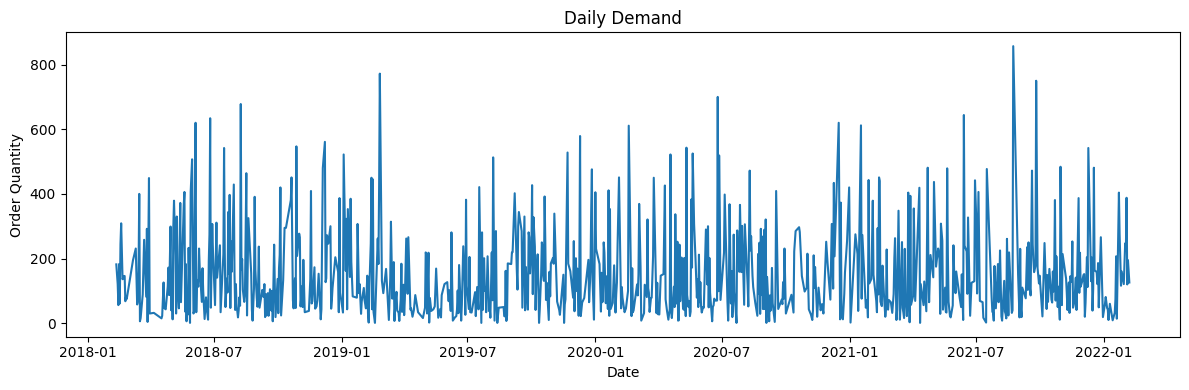

In [21]:
plt.figure(figsize=(12,4))
plt.plot(ts_data['Order Date'], ts_data['Order Quantity'])
plt.title('Daily Demand')
plt.xlabel('Date')
plt.ylabel('Order Quantity')
plt.tight_layout()
plt.show()

The time series visualisation shows that retail demand fluctuates considerably over time, with several noticeable peaks in daily order quantities. These variations suggest the presence of dynamic purchasing behaviour and potential seasonal or promotional effects. Organising the dataset into a chronological time-series structure is an essential step for developing accurate retail demand forecasting models.


### Interpretation of the Results

The graph shows that daily retail demand fluctuates significantly over time.

Some days have:

* Very high order quantities
* Sudden demand spikes
* Low purchasing activity

This indicates that retail demand is dynamic and changes frequently.


### Key Observations
Demand Fluctuation

The dataset shows large variations in daily sales quantities. This suggests:

* Customer purchasing behaviour changes over time
* Demand is not constant
* Some days experience significantly higher sales activity

### Demand Peaks

Several sharp spikes appear in the graph.

Possible reasons may include:

* Promotional campaigns
* Seasonal shopping periods
* Bulk customer purchases
* Special sales events

### Irregular Sales Patterns

The data appears noisy and highly variable, which is common in retail forecasting problems.

This indicates the forecasting model must handle:

* Volatility
* Sudden changes
* Nonlinear demand behaviour

## Testing for stationarity

In [22]:
from statsmodels.tsa.stattools import adfuller

test_result = adfuller(ts_data['Order Quantity'])

In [23]:

#Ho: It is non stationary
#H1: It is stationary

def adf_test(series):

    result = adfuller(series)

    labels = [
        'ADF Test Statistic',
        'p-value',
        '#Lags Used',
        'Number of Observations Used'
    ]

    for value, label in zip(result[:4], labels):
        print(f'{label}: {value}')

    if result[1] <= 0.05:
        print("\nStrong evidence against the null hypothesis.")
        print("The time series is stationary.")
    else:
        print("\nWeak evidence against the null hypothesis.")
        print("The time series is non-stationary.")

# Run test
adf_test(ts_data['Order Quantity'])

ADF Test Statistic: -19.77639989048792
p-value: 0.0
#Lags Used: 1
Number of Observations Used: 879

Strong evidence against the null hypothesis.
The time series is stationary.


The Augmented Dickey-Fuller (ADF) test produced a test statistic of -19.78 and a p-value below 0.05.

Since the p-value is significantly smaller than the significance level, the null hypothesis of a unit root is rejected. Therefore, the time series is considered stationary.

### Convert Daily → Weekly Demand to reduce the noicyness

In [24]:
# Set date as index
ts_data = ts_data.set_index('Order Date')

# Aggregate weekly demand
weekly_data = ts_data['Order Quantity'].resample('W').sum()

weekly_data.head()

,Order Quantity
Order Date,
2018-02-11,182.0
2018-02-18,975.0
2018-02-25,579.0
2018-03-04,75.0
2018-03-11,426.0


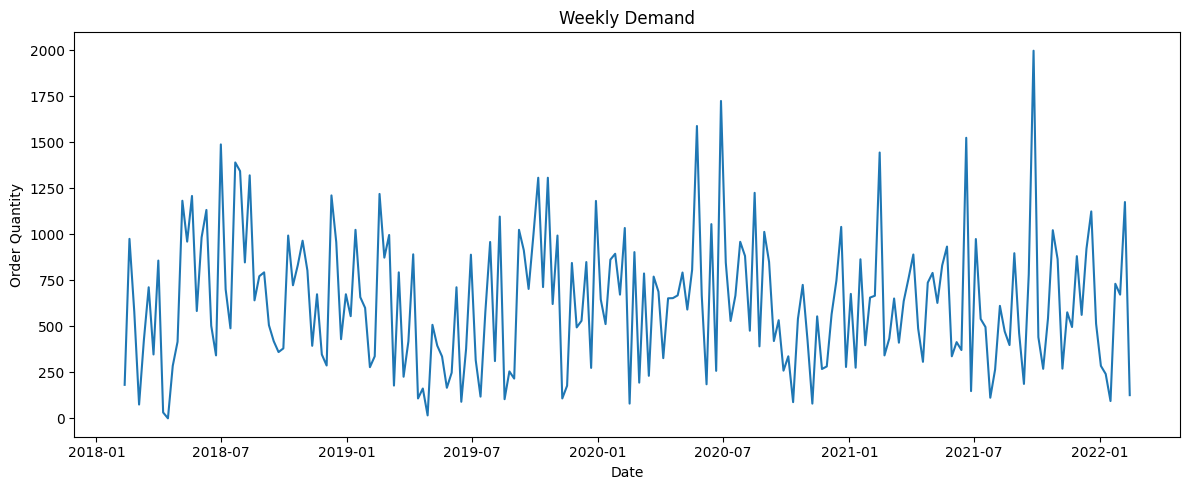

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(weekly_data)

plt.title('Weekly Demand')

plt.xlabel('Date')

plt.ylabel('Order Quantity')

plt.tight_layout()

plt.show()

In [26]:
def adf_test(series):

    result = adfuller(series)

    labels = [
        'ADF Test Statistic',
        'p-value',
        '#Lags Used',
        'Number of Observations Used'
    ]

    for value, label in zip(result[:4], labels):
        print(f'{label}: {value}')

    if result[1] <= 0.05:
        print("\nStrong evidence against the null hypothesis.")
        print("The time series is stationary.")
    else:
        print("\nWeak evidence against the null hypothesis.")
        print("The time series is non-stationary.")

# Run test
adf_test(weekly_data)

ADF Test Statistic: -13.944361617907699
p-value: 4.827415565250191e-26
#Lags Used: 0
Number of Observations Used: 209

Strong evidence against the null hypothesis.
The time series is stationary.


### Monthly demand trend

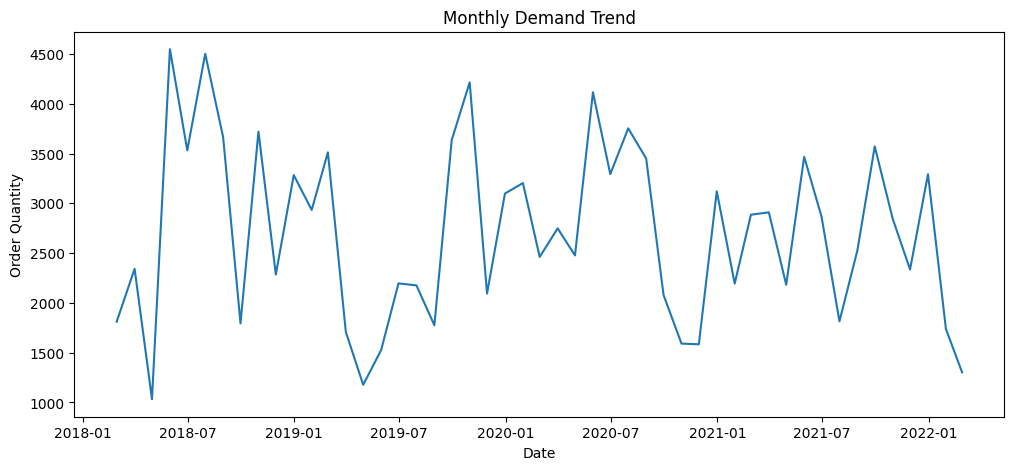

In [27]:
monthly_data = ts_data['Order Quantity'].resample('M').sum()

plt.figure(figsize=(12,5))

plt.plot(monthly_data)

plt.title('Monthly Demand Trend')

plt.xlabel('Date')

plt.ylabel('Order Quantity')

plt.show()

### Scale the Data

In [28]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(
    weekly_data.values.reshape(-1,1)
)
scaled_data

array([[0.09113671],
       [0.48823235],
       [0.2899349 ],
       [0.03755633],
       [0.21331998],
       [0.3565348 ],
       [0.17376064],
       [0.42914372],
       [0.01602404],
       [0.        ],
       [0.14271407],
       [0.20831247],
       [0.59188783],
       [0.48072108],
       [0.60490736],
       [0.29193791],
       [0.49223836],
       [0.56685028],
       [0.25187782],
       [0.17125689],
       [0.74511768],
       [0.35102654],
       [0.2448673 ],
       [0.69604407],
       [0.67250876],
       [0.4241362 ],
       [0.66099149],
       [0.32098147],
       [0.38657987],
       [0.39709564],
       [0.25338007],
       [0.20981472],
       [0.18027041],
       [0.19028543],
       [0.49724587],
       [0.36204306],
       [0.41662494],
       [0.48322484],
       [0.40210315],
       [0.19729594],
       [0.33750626],
       [0.17376064],
       [0.14371557],
       [0.60640961],
       [0.47921883],
       [0.21532298],
       [0.33750626],
       [0.277

### Create Sequential Data

In [29]:
WINDOW_SIZE = 12  # or 24

def create_sequences(data, window_size=WINDOW_SIZE):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, window_size=WINDOW_SIZE)

### Splitting the dataset into Train/Test and validation

In [30]:
n = len(X)
train_size = int(0.7 * n)
val_size = int(0.15 * n)
test_size = n - train_size - val_size

X_train = X[:train_size]
X_val   = X[train_size : train_size + val_size]
X_test  = X[train_size + val_size :]

y_train = y[:train_size]
y_val   = y[train_size : train_size + val_size]
y_test  = y[train_size + val_size :]

print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)
print("y_train:", y_train.shape)
print("y_val:  ", y_val.shape)
print("y_test: ", y_test.shape)

X_train: (138, 12, 1)
X_val:   (29, 12, 1)
X_test:  (31, 12, 1)
y_train: (138, 1)
y_val:   (29, 1)
y_test:  (31, 1)


### Simple neural network with LSTM

In [31]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential()
model.add(
    LSTM(
        128,
        activation="tanh",
        recurrent_activation="sigmoid",
        return_sequences=True,
        input_shape=(X_train.shape[1], X_train.shape[2]),
    )
)
model.add(
    LSTM(
        64,
        activation="tanh",
        recurrent_activation="sigmoid",
        return_sequences=False,
    )
)
model.add(Dense(32, activation="relu"))
model.add(Dense(1))

model.compile(optimizer="adam", loss="mse")

earlystop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
)

history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=4,
    validation_data=(X_val, y_val),
    callbacks=[earlystop],
    verbose=1,
)

Epoch 1/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 0.0501 - val_loss: 0.0260
Epoch 2/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0346 - val_loss: 0.0272
Epoch 3/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0324 - val_loss: 0.0264
Epoch 4/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0339 - val_loss: 0.0258
Epoch 5/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0339 - val_loss: 0.0260
Epoch 6/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0338 - val_loss: 0.0266
Epoch 7/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0341 - val_loss: 0.0262
Epoch 8/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0322 - val_loss: 0.0279
Epoch 9/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0339 - val_loss: 0.0298
Epoch 10/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0330 - val_loss: 0.0261
Epoch 11/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0323 - val_loss: 0.0289
Epoch 12/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step

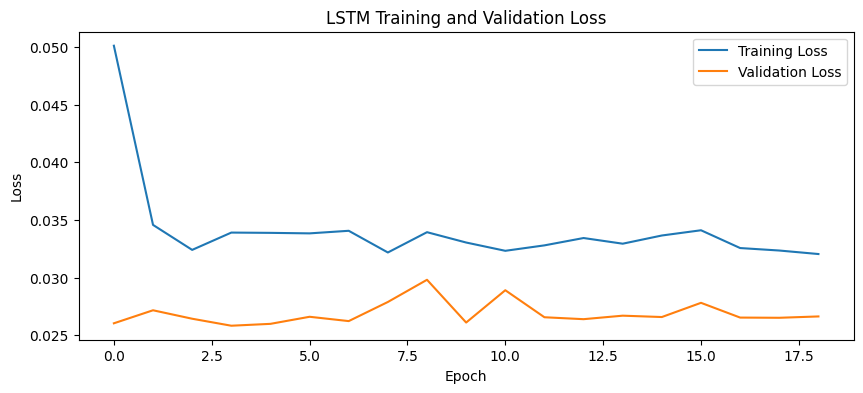

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.plot(history.history['loss'], label='Training Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('LSTM Training and Validation Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend()

plt.show()

### Observation of the LSTM Model

The LSTM model demonstrated stable learning performance during the training process. The training loss decreased significantly from approximately 0.050 in the first epoch to around 0.032 in the final epochs, indicating that the model successfully learned important patterns from the retail demand time-series data. Similarly, the validation loss remained relatively low and stable throughout training, fluctuating around 0.026 to 0.029. This suggests that the model generalised well to unseen validation data and did not suffer from significant overfitting.

The gap between the training loss and validation loss remained small, which indicates a balanced learning process and good model stability. The use of the EarlyStopping callback also helped prevent unnecessary training once the model performance stopped improving, improving computational efficiency and reducing overfitting risk. Overall, the LSTM model appears effective for capturing temporal demand patterns and forecasting retail order quantities from historical sales data.

The LSTM training and validation loss curves do not show strong signs of overfitting, as both losses remain relatively close and stable throughout the training process. The validation loss does not increase significantly during later epochs, indicating that the model generalises reasonably well to unseen data. However, the dataset size is relatively small for deep learning applications, with only 138 training samples available. As a result, the model may have limited ability to fully capture complex temporal patterns, and the forecasting performance could potentially improve with a larger time-series dataset containing more observations and features.

In [33]:
predictions = model.predict(X_test)

predictions = scaler.inverse_transform(predictions)

y_test_actual = scaler.inverse_transform(y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step


In [34]:
# Predict on test set (scaled)
y_pred_scaled = model.predict(X_test)

# Ensure y_test is 2-D for inverse_transform
y_test_scaled = y_test.reshape(-1, 1)

# Inverse transform to original scale
y_pred = scaler.inverse_transform(y_pred_scaled).ravel()
y_test_actual = scaler.inverse_transform(y_test_scaled).ravel()

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
MAE: 304.76253780241933
RMSE: 399.15489214478134


In [35]:
print("y_test_actual range:", y_test_actual.min(), y_test_actual.max())
print("y_pred range:", y_pred.min(), y_pred.max())
print("First 10 actual:", y_test_actual[:10])
print("First 10 pred:  ", y_pred[:10])

y_test_actual range: 94.0 1997.0
y_pred range: 564.3192 658.6146
First 10 actual: [496. 112. 265. 611. 472. 398. 897. 462. 187. 782.]
First 10 pred:   [642.38586 636.63965 617.8477  598.08887 584.8119  573.50415 569.1291
 577.0001  581.58746 564.3192 ]


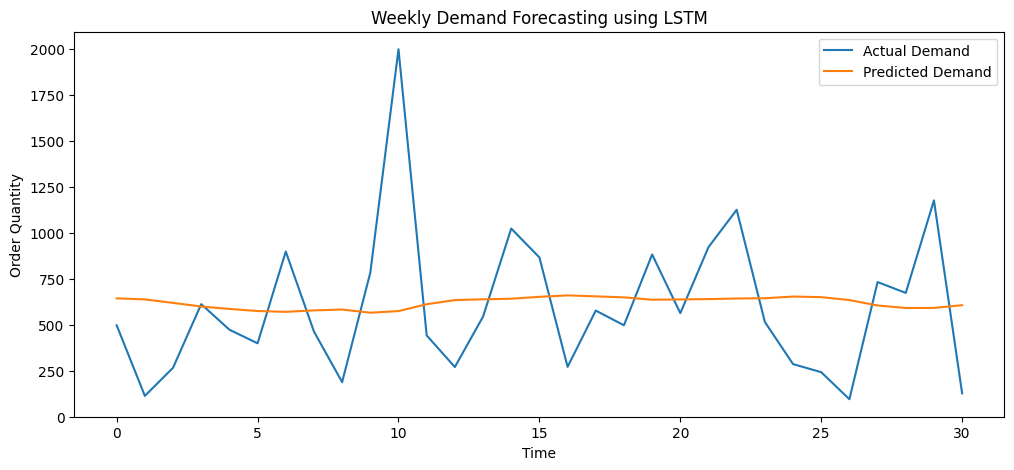

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(y_test_actual, label='Actual Demand')

plt.plot(predictions, label='Predicted Demand')

plt.title('Weekly Demand Forecasting using LSTM')

plt.xlabel('Time')

plt.ylabel('Order Quantity')

plt.legend()

plt.show()

The LSTM forecasting results show that the model was able to learn the general trend of retail demand over time; however, its predictive performance on the test dataset appears limited. The actual demand values fluctuate significantly with several sharp peaks and sudden drops, while the predicted demand remains relatively smooth and stable around the average demand level. This indicates that the model struggled to capture extreme variations and sudden changes in customer purchasing behaviour.

The evaluation metrics also suggest moderate forecasting accuracy, with a Mean Absolute Error (MAE) of approximately 304.77 and a Root Mean Squared Error (RMSE) of around 399.15. The higher RMSE value indicates that the model produced larger prediction errors for some high-demand periods. One possible reason for this behaviour is the relatively small dataset size, which limits the LSTM model’s ability to learn complex temporal patterns effectively. Additionally, the model may be underfitting the data, as the predictions appear overly smoothed and unable to follow the volatility of the actual demand series.

Despite these limitations, the model still demonstrates the capability of using historical time-series data for retail demand forecasting. Further improvements could potentially be achieved by increasing the dataset size, adding more input features, tuning hyperparameters, or experimenting with advanced forecasting architectures such as Bidirectional LSTM or GRU models.

In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test_actual, predictions)
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 304.76253780241933
RMSE: 399.15489214478134


### Simple neural network without LSTM

In [38]:
from tensorflow import keras
from tensorflow.keras import layers

input_dim = X_train.shape[1]
output_dim = y_train.shape[1]

model = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(64, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(output_dim)  # 7 outputs for t+1..t+7
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

callback = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=8,
    callbacks=[callback],
    verbose=1,
)

Epoch 1/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.1281 - mae: 0.2784 - val_loss: 0.0385 - val_mae: 0.1605
Epoch 2/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0410 - mae: 0.1679 - val_loss: 0.0306 - val_mae: 0.1348
Epoch 3/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0329 - mae: 0.1468 - val_loss: 0.0303 - val_mae: 0.1350
Epoch 4/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0322 - mae: 0.1450 - val_loss: 0.0299 - val_mae: 0.1357
Epoch 5/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0316 - mae: 0.1430 - val_loss: 0.0300 - val_mae: 0.1362
Epoch 6/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0305 - mae: 0.1418 - val_loss: 0.0307 - val_mae: 0.1378
Epoch 7/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0305 - mae: 0.1409 - val_loss: 0.0311 - val_mae: 0.1395
Epoch 8/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0293 - mae: 0.1384 - val_loss: 0.0317 - val_mae: 0.1402
Epoch 9/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.

In [39]:
predictions = model.predict(X_test)

predictions = scaler.inverse_transform(predictions)

y_test_actual = scaler.inverse_transform(y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


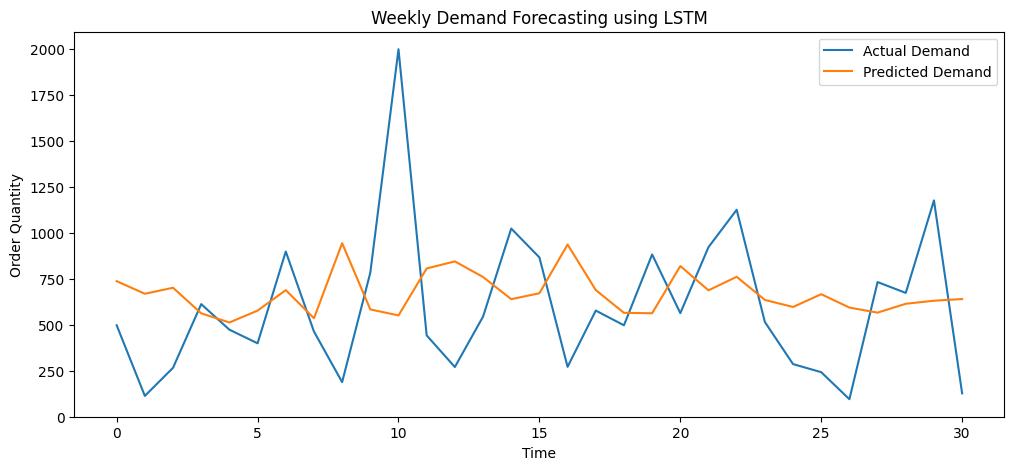

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(y_test_actual, label='Actual Demand')

plt.plot(predictions, label='Predicted Demand')

plt.title('Weekly Demand Forecasting using LSTM')

plt.xlabel('Time')

plt.ylabel('Order Quantity')

plt.legend()

plt.show()

The forecasting results from the simple neural network model without LSTM show that the model was able to capture the general average trend of retail demand, but it struggled to accurately follow the large fluctuations and sudden peaks in the actual demand values. The predicted demand curve appears smoother and more stable compared to the actual demand line, indicating that the model could not fully learn the complex temporal patterns and volatility present in the time-series data.

Although the model produced reasonable predictions for moderate demand periods, it failed to accurately predict extreme high-demand spikes, such as the sharp increase observed around the middle of the testing period. This behaviour suggests that the simple feedforward neural network has limited capability for modelling sequential dependencies and temporal relationships in time-series forecasting problems. Since the model does not contain memory-based components like LSTM layers, it cannot effectively retain information from previous time steps.

Additionally, the relatively small dataset size may have further limited the learning performance of the neural network. Overall, the model demonstrates basic forecasting capability; however, its predictions are overly smoothed and less responsive to rapid changes in retail demand. This highlights the importance of sequence-based architectures such as LSTM for capturing temporal dynamics in demand forecasting applications.

# Simple model with Random Forest

In [41]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Reshape X_train and X_test from 3D to 2D
X_train_reshaped = X_train.reshape(X_train.shape[0], -1)
X_test_reshaped = X_test.reshape(X_test.shape[0], -1)

# Flatten y_train and y_test from 2D to 1D
y_train_flattened = y_train.ravel()
y_test_flattened = y_test.ravel()

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_reshaped, y_train_flattened)

y_pred = rf.predict(X_test_reshaped)

mae = mean_absolute_error(y_test_flattened, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_flattened, y_pred))
print("MAE:", mae)
print("RMSE:", rmse)


MAE: 0.16299416867236335
RMSE: 0.21286607766495286


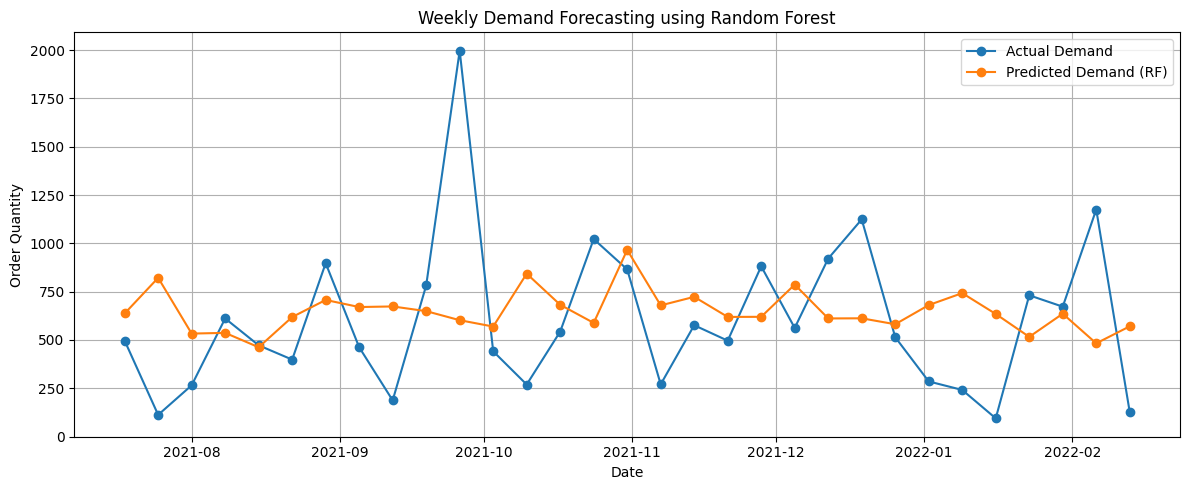

In [42]:
import matplotlib.pyplot as plt
import numpy as np

# Inverse-transform back to original scale
y_test_actual = scaler.inverse_transform(y_test_flattened.reshape(-1, 1)).ravel()
y_pred_actual = scaler.inverse_transform(y_pred.reshape(-1, 1)).ravel()

# Build time index for test period (last len(y_test) weeks)
test_index = weekly_data.index[-len(y_test_flattened):]

plt.figure(figsize=(12, 5))
plt.plot(test_index, y_test_actual, label='Actual Demand', marker='o')
plt.plot(test_index, y_pred_actual, label='Predicted Demand (RF)', marker='o')

plt.title('Weekly Demand Forecasting using Random Forest')
plt.xlabel('Date')
plt.ylabel('Order Quantity')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

The Random Forest forecasting model demonstrated moderate performance in predicting weekly retail demand patterns. Compared to the neural network models, the Random Forest predictions followed the fluctuations in the actual demand data more closely in some periods; however, the model still struggled to accurately capture extreme demand spikes and sudden drops. The predicted demand values remained relatively concentrated around the average range, while the actual demand series showed high volatility and sharp variations over time.

The evaluation metrics indicate reasonable model accuracy, with a Mean Absolute Error (MAE) of approximately 0.16 and a Root Mean Squared Error (RMSE) of around 0.21 in the scaled data format. These relatively low error values suggest that the Random Forest model was able to learn useful relationships within the historical demand data. The ensemble structure of Random Forest helps improve prediction stability by combining multiple decision trees, making it less sensitive to noise compared to some neural network approaches.

However, the model still appears to underpredict high-demand peaks, such as the large spike observed during the middle of the testing period. This limitation may be caused by the relatively small dataset size and the highly irregular nature of retail demand patterns. Since Random Forest is not specifically designed for sequential time-series memory learning, it may not fully capture long-term temporal dependencies in the data.

Overall, the Random Forest model provides stable and reasonably accurate forecasting performance for general demand trends, but its ability to predict sudden demand surges remains limited. Further improvements could potentially be achieved through feature engineering, additional historical data, or advanced sequence-based forecasting models.

### Comparison of Forecasting Models
The forecasting results indicate that the Random Forest model achieved the best overall performance among the three evaluated approaches. Although the LSTM model demonstrated stable learning behaviour and successfully captured some temporal demand patterns, its performance was limited by the relatively small dataset size. The simple neural network without LSTM showed the weakest forecasting capability, as it produced overly smooth predictions and failed to capture significant demand fluctuations. In comparison, the Random Forest model generated more responsive predictions that followed the actual demand variations more closely, making it the most suitable forecasting approach for this retail demand dataset.